In [1]:
library(clusterProfiler)
library(org.Hs.eg.db)
library(enrichplot)
library(ggplot2)
library(dplyr)
library(DOSE)



clusterProfiler v4.10.0  For help: https://yulab-smu.top/biomedical-knowledge-mining-book/

If you use clusterProfiler in published research, please cite:
T Wu, E Hu, S Xu, M Chen, P Guo, Z Dai, T Feng, L Zhou, W Tang, L Zhan, X Fu, S Liu, X Bo, and G Yu. clusterProfiler 4.0: A universal enrichment tool for interpreting omics data. The Innovation. 2021, 2(3):100141


Attaching package: ‘clusterProfiler’


The following object is masked from ‘package:stats’:

    filter


Loading required package: AnnotationDbi

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, 

In [43]:
# 使用基础R函数读取CSV文件
marker_niche <- read.csv("/cluster2/huanglab/jiamao/Project/Tools/nichecompass-reproducibility/artifacts/stereo_seq_spinal_cord_gwall/results/single_sample/27052025_044245/marker_niche.csv")
# 查看前几行数据
head(marker_niche)

,group,names,scores,logfoldchanges,pvals,pvals_adj
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
1,Dorsal_Horn,STMN2,41.17065,2.330162,0.000000e+00,0.000000e+00
2,Dorsal_Horn,RBFOX1,33.37581,2.261368,3.076552e-244,1.229236e-240
3,Dorsal_Horn,SOX4,30.73203,2.342183,2.126107e-207,5.663239e-204
4,Dorsal_Horn,EBF3,28.48066,3.121847,2.034070e-178,4.063563e-175
5,Dorsal_Horn,NPY,26.00226,3.991660,4.668904e-149,6.218201e-146
6,Dorsal_Horn,MALAT1,25.96397,1.452421,1.264724e-148,1.443773e-145


In [36]:
table(top_100_marker_niche$group)


            Dorsal_Horn       Intermediate_Gray            Ventral_Horn 
                    100                     100                     100 
Early_Horn/Lateral_Horn                 MN_Horn      Early_White_Matter 
                    100                      28                      24 
           White_Matter                      VZ                 Meninge 
                    100                     100                     100 
                 Cavity 
                     14 

In [44]:
top_100_marker_niche <- marker_niche %>%
  group_by(group) %>%
  arrange(desc(logfoldchanges), .by_group = TRUE) %>%
  slice_head(n = 100) %>%
  ungroup()

In [45]:
# 查看当前 group 的类别和顺序
levels(factor(top_100_marker_niche$group))

[1] "Cavity"                  "Dorsal_Horn"            
 [3] "Early_Horn/Lateral_Horn" "Early_White_Matter"     
 [5] "Intermediate_Gray"       "Meninge"                
 [7] "MN_Horn"                 "Ventral_Horn"           
 [9] "VZ"                      "White_Matter"

In [46]:
top_100_marker_niche$group <- factor(top_100_marker_niche$group, 
                            levels = c("Dorsal_Horn",
                                    "Intermediate_Gray",
                                    "Ventral_Horn",
                                    "Early_Horn/Lateral_Horn",
                                    "MN_Horn",
                                    "Early_White_Matter",
                                    "White_Matter",
                                    "VZ",
                                    "Meninge",
                                    "Cavity"))

levels(top_100_marker_niche$group)

[1] "Dorsal_Horn"             "Intermediate_Gray"      
 [3] "Ventral_Horn"            "Early_Horn/Lateral_Horn"
 [5] "MN_Horn"                 "Early_White_Matter"     
 [7] "White_Matter"            "VZ"                     
 [9] "Meninge"                 "Cavity"

In [51]:
gene_list <- split(top_100_marker_niche$names, top_100_marker_niche$group)
go <- compareCluster(gene_list, 
                        fun="enrichGO", 
                        OrgDb = org.Hs.eg.db, 
                        ont='BP',
                        pAdjustMethod = 'BH',
                        pvalueCutoff = 0.05, 
                        keyType = 'SYMBOL')

In [54]:
as.data.frame(go)

Cluster,ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count
<fct>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>
Dorsal_Horn,GO:0007416,synapse assembly,10/94,200/18870,5.961342e-08,0.0001024755,0.0000875376,KIRREL3/NEGR1/ROBO2/EFNA5/PTPRD/ERBB4/LINGO2/NLGN1/PCLO/DSCAM,10
Dorsal_Horn,GO:0031346,positive regulation of cell projection organization,12/94,355/18870,1.953674e-07,0.0001679183,0.0001434408,TENM3/STMN2/NRP1/NEGR1/ROBO2/EFNA5/CDC42EP3/PTPRD/CCP110/NLGN1/FNBP1L/DSCAM,12
Dorsal_Horn,GO:0010975,regulation of neuron projection development,12/94,453/18870,2.549404e-06,0.0014608083,0.0012478660,SKOR2/SPOCK1/TENM3/STMN2/NRP1/NEGR1/ROBO2/EFNA5/PPP3CA/PTPRD/NLGN1/DSCAM,12
Dorsal_Horn,GO:0050808,synapse organization,12/94,483/18870,4.917049e-06,0.0021131020,0.0018050747,KIRREL3/NRP1/NEGR1/ROBO2/EFNA5/PTPRD/ERBB4/LINGO2/NLGN1/PCLO/VHL/DSCAM,12
Dorsal_Horn,GO:0098742,cell-cell adhesion via plasma-membrane adhesion molecules,9/94,279/18870,1.053614e-05,0.0036223256,0.0030942985,TENM3/KIRREL3/FAT4/ROBO2/EFNA5/PTPRD/CNTN4/NLGN1/DSCAM,9
Dorsal_Horn,GO:0034329,cell junction assembly,11/94,446/18870,1.345711e-05,0.0038554609,0.0032934497,KIRREL3/NRP1/NEGR1/ROBO2/EFNA5/PTPRD/ERBB4/LINGO2/NLGN1/PCLO/DSCAM,11
Dorsal_Horn,GO:0051963,regulation of synapse assembly,6/94,114/18870,2.250498e-05,0.0055265803,0.0047209696,NEGR1/ROBO2/EFNA5/PTPRD/LINGO2/NLGN1,6
Dorsal_Horn,GO:0001764,neuron migration,7/94,177/18870,2.922875e-05,0.0057495422,0.0049114304,TLX3/CCK/SPOCK1/SCRT1/KIRREL3/LHX1/NRP1,7
Dorsal_Horn,GO:0031112,positive regulation of microtubule polymerization or depolymerization,4/94,36/18870,3.010232e-05,0.0057495422,0.0049114304,STMN2/HSPA1B/AKAP9/NAV3,4


Scale for y is already present.
Adding another scale for y, which will replace the existing scale.


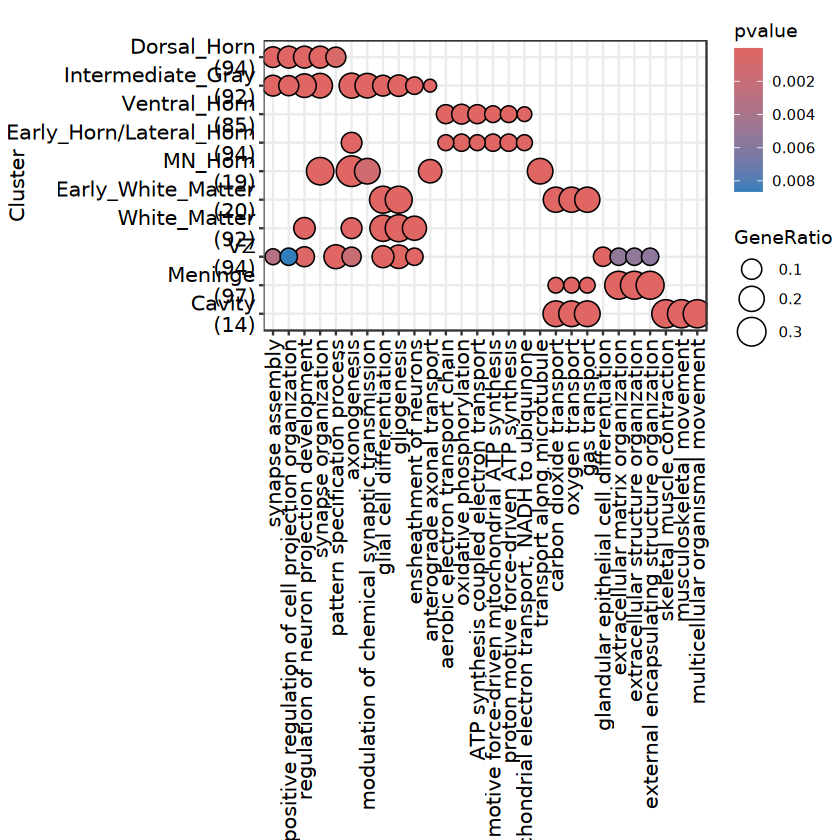

In [52]:
p <- dotplot(go, showCategory= 3, color="pvalue") + 
  scale_color_continuous(low='#C0D6E8', high='firebrick3') +
  coord_flip() +
  scale_x_discrete(limits = rev) + 
  scale_y_discrete(limits = rev) + 
  theme(axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5))
p

In [41]:
# 保存为 PDF（推荐方式）
ggsave(
  filename = "BP_enrichment_plot.pdf",  # 输出文件名
  plot = p,                         # 绘图对象
  device = "pdf",                   # 设备类型
  width = 12,                       # 宽度（英寸）
  height = 12,                       # 高度（英寸）
  units = "in",                     # 单位
  dpi = 300                         # 分辨率（适用于栅格元素）
)

In [30]:
early_horn_genes <- gene_list[["Early_Horn/Lateral_Horn"]]
go_early_horn <- enrichGO(gene = early_horn_genes,
                         OrgDb = org.Hs.eg.db,
                         ont = 'BP',
                         pAdjustMethod = 'BH',
                         pvalueCutoff = 0.5,
                         qvalueCutoff = 0.5,
                         keyType = 'SYMBOL')

# 查看结果
head(go_early_horn)

,ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>
GO:0031103,GO:0031103,axon regeneration,2/13,52/18870,0.0005697808,0.07913561,0.04964801,GAP43/NEFL,2
GO:0031102,GO:0031102,neuron projection regeneration,2/13,58/18870,0.0007086384,0.07913561,0.04964801,GAP43/NEFL,2
GO:0051258,GO:0051258,protein polymerization,3/13,286/18870,0.0008803897,0.07913561,0.04964801,STMN2/NEFL/TMSB10,3
GO:0045109,GO:0045109,intermediate filament organization,2/13,73/18870,0.0011200727,0.07913561,0.04964801,NEFL/NEFM,2
GO:0032272,GO:0032272,negative regulation of protein polymerization,2/13,80/18870,0.0013431575,0.07913561,0.04964801,STMN2/TMSB10,2
GO:0048678,GO:0048678,response to axon injury,2/13,84/18870,0.0014794232,0.07913561,0.04964801,GAP43/NEFL,2


In [1]:
library(enrichR)
listEnrichrSites()
setEnrichrSite("Enrichr") # Human genes
dbs <- c("GO_Molecular_Function_2025", "GO_Biological_Process_2025")

Welcome to enrichR
Checking connections ... 

Enrichr ... 
Connection is Live!

FlyEnrichr ... 
Connection is Live!

WormEnrichr ... 
Connection is Live!

YeastEnrichr ... 
Connection is Live!

FishEnrichr ... 
Connection is Live!

OxEnrichr ... 
Connection is Live!

Enrichr ... 
Connection is Live!

FlyEnrichr ... 
Connection is Live!

WormEnrichr ... 
Connection is Live!

YeastEnrichr ... 
Connection is Live!

FishEnrichr ... 
Connection is Live!

OxEnrichr ... 
Connection is Live!

Connection changed to https://maayanlab.cloud/Enrichr/

Connection is Live!



In [3]:
packageVersion("enrichR")

[1] ‘3.4’

In [6]:
# 使用基础R函数读取CSV文件
marker_niche <- read.csv("/cluster2/huanglab/jiamao/Project/Tools/nichecompass-reproducibility/artifacts/stereo_seq_spinal_cord_gwall/results/single_sample/27052025_044245/marker_niche.csv")
# 查看前几行数据
head(marker_niche)

,group,names,scores,logfoldchanges,pvals,pvals_adj
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
1,Dorsal_Horn,STMN2,38.08866,2.421237,0.000000e+00,0.000000e+00
2,Dorsal_Horn,RBFOX1,26.02787,2.206044,2.395824e-149,9.572513e-146
3,Dorsal_Horn,TMSB10,23.47905,1.435169,6.677732e-122,1.778725e-118
4,Dorsal_Horn,SST,21.48617,2.430249,2.097293e-102,3.351894e-99
5,Dorsal_Horn,NPY,20.55990,3.920345,6.275639e-94,6.268579e-91
6,Dorsal_Horn,EBF3,20.42975,3.025747,9.097202e-93,8.077304e-90


In [7]:
top_100_marker_niche <- marker_niche %>%
  group_by(group) %>%
  arrange(desc(logfoldchanges), .by_group = TRUE) %>%
  slice_head(n = 100) %>%
  ungroup()
gene_list <- split(top_100_marker_niche$names, top_100_marker_niche$group)

In [ ]:
# 循环处理每个组
for (group_name in names(gene_list)) {
  # 获取当前组的基因
  genes <- gene_list[[group_name]]
  
  # 进行GO富集分析
  enriched <- enrichr(genes, dbs)
  
  # 处理分子功能结果
  mf <- enriched$GO_Molecular_Function_2025
  Name <- 'GO Molecular Function 2025'
  mf <- cbind(Name, mf)
  
  # 处理生物过程结果
  bp <- enriched$GO_Biological_Process_2025
  Name <- 'GO Biological Process 2025'
  bp <- cbind(Name, bp)
  
  # 合并结果并按调整p值排序
  df <- rbind(mf, bp)
  df <- df[order(df$Adjusted.P.value), ]
  
  # 创建安全的文件名（替换特殊字符）
  safe_group_name <- gsub("[^[:alnum:]]", "_", group_name)
  file_name <- paste0("/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ST/niche/GWall/", 
                     safe_group_name, "_spDEG_GO.txt")
  
  # 保存结果
  write.table(df, file_name, quote = FALSE, row.names = FALSE, sep = "\t")
  
  message(paste("save:", group_name))
}

In [ ]:
cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ST/niche/GWall